In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns

In [2]:
df = pd.read_csv("/content/TASK 3 Symptom2Disease.csv")
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [3]:
df.shape

(1200, 3)

In [4]:
df.columns

Index(['Unnamed: 0', 'label', 'text'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1200 non-null   int64 
 1   label       1200 non-null   object
 2   text        1200 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.3+ KB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
label,0
text,0


In [7]:
df = df.dropna()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [11]:
df['label'].unique()

array(['Psoriasis', 'Varicose Veins', 'Typhoid', 'Chicken pox',
       'Impetigo', 'Dengue', 'Fungal infection', 'Common Cold',
       'Pneumonia', 'Dimorphic Hemorrhoids', 'Arthritis', 'Acne',
       'Bronchial Asthma', 'Hypertension', 'Migraine',
       'Cervical spondylosis', 'Jaundice', 'Malaria',
       'urinary tract infection', 'allergy',
       'gastroesophageal reflux disease', 'drug reaction',
       'peptic ulcer disease', 'diabetes'], dtype=object)

In [12]:
df['label'].value_counts()

,count
label,
Psoriasis,50
Varicose Veins,50
Typhoid,50
Chicken pox,50
Impetigo,50
Dengue,50
Fungal infection,50
Common Cold,50
Pneumonia,50


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

In [15]:
df.replace({
    'Yes':1,
    'No':0
}, inplace=True)

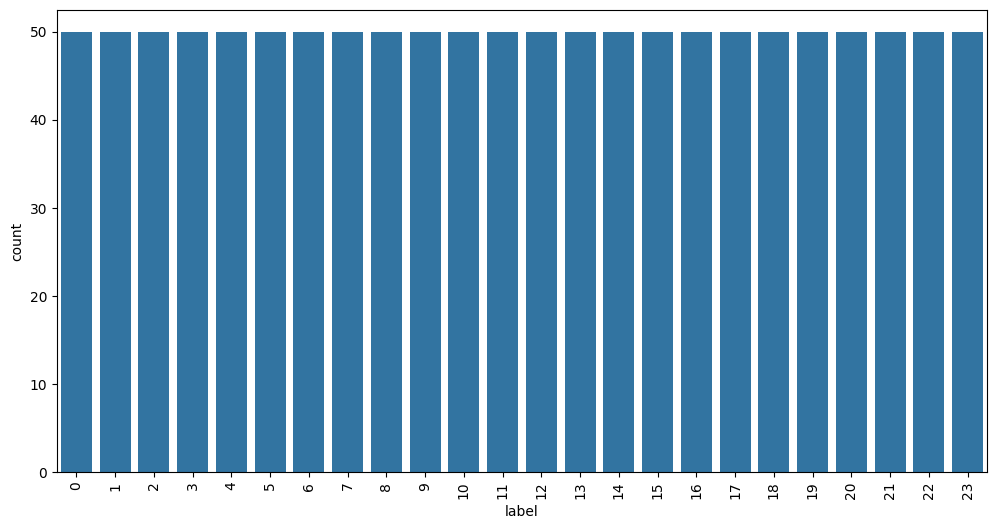

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.show()

In [19]:
X = df.drop(['Unnamed: 0', 'label'], axis='columns')
y = df['label']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=10
)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to manage complexity

# Fit and transform the training data, then transform the test data
X_train_vectorized = vectorizer.fit_transform(X_train['text'])
X_test_vectorized = vectorizer.transform(X_test['text'])

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_vectorized, y_train)

lr.score(X_test_vectorized, y_test)

0.9666666666666667

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train_vectorized, y_train)

dt.score(X_test_vectorized, y_test)

0.8375

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_vectorized, y_train)

rf.score(X_test_vectorized, y_test)

0.9583333333333334

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_vectorized, y_train)

knn.score(X_test_vectorized, y_test)

0.9458333333333333

In [30]:
from sklearn.model_selection import cross_val_score

# Vectorize the full X dataset's 'text' column
X_vectorized_full = vectorizer.transform(X['text'])

cross_val_score(rf, X_vectorized_full, y, cv=5)

array([0.9       , 0.96666667, 0.96666667, 0.97083333, 0.95416667])

In [31]:
def predict_disease(symptoms):

    prediction = rf.predict([symptoms])

    disease_name = le.inverse_transform(prediction)

    return disease_name[0]

In [33]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test_vectorized)

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 8,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  7,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  8,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  2,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  1,
         1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  8,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 11,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0, 

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        10
           2       0.88      1.00      0.93         7
           3       0.89      1.00      0.94         8
           4       0.82      0.90      0.86        10
           5       1.00      0.93      0.96        14
           6       0.67      0.29      0.40         7
           7       1.00      1.00      1.00         8
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         9
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00        16
          15       0.92      1.00      0.96        12
          16       0.85      0.85      0.85        13
          17       1.00    

In [35]:
import pickle

with open('disease_prediction_model.pickle','wb') as f:
    pickle.dump(rf, f)

In [36]:
import json

columns = {
    'data_columns': [col.lower() for col in X.columns]
}

with open("columns.json","w") as f:
    f.write(json.dumps(columns))